In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

In [2]:
# -----------------------------
# 1. Define the "blackbox" function
# -----------------------------
def f(x):
    return np.sin(x)


In [3]:
# -----------------------------
# 2. Set up the GP model
# -----------------------------
# Kernel: Constant * RBF (squared exponential)
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 10))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


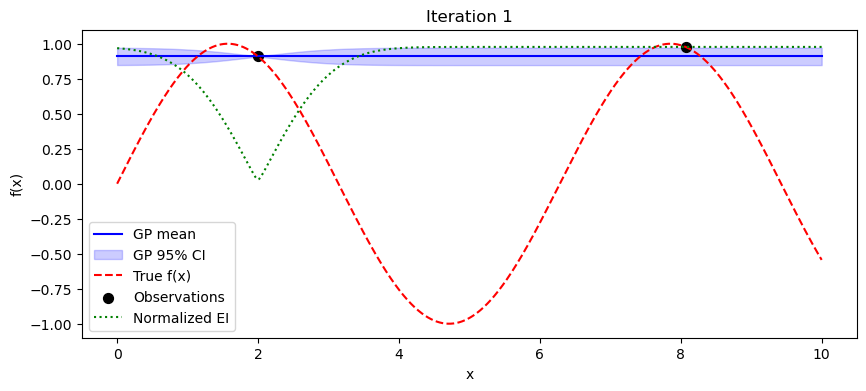

Iteration 1: Next x = 8.068, y = 0.977


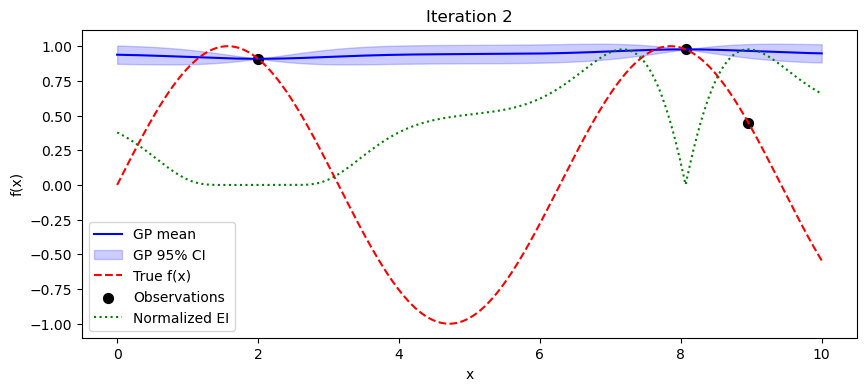

Iteration 2: Next x = 8.959, y = 0.449


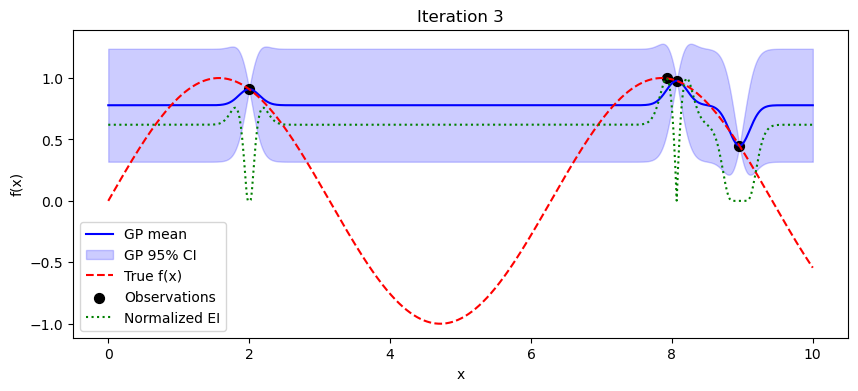

Iteration 3: Next x = 7.928, y = 0.997


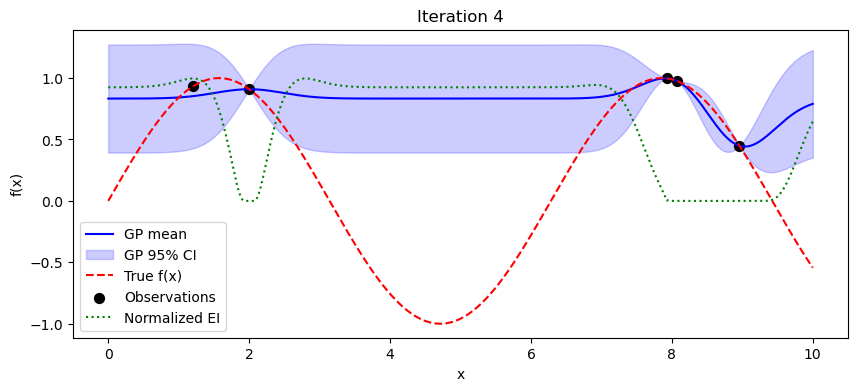

Iteration 4: Next x = 1.201, y = 0.932


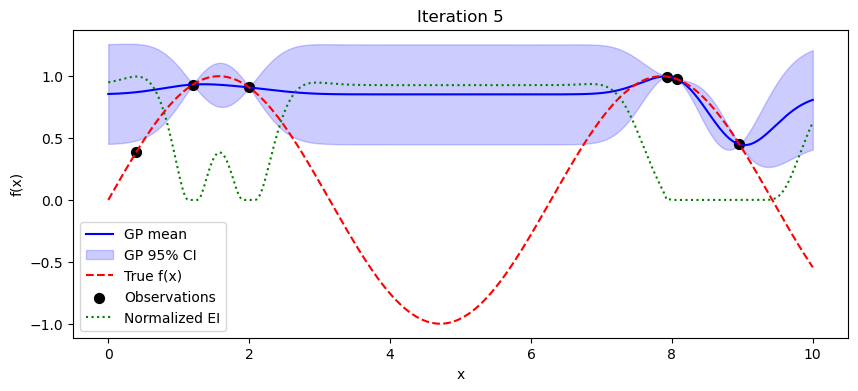

Iteration 5: Next x = 0.400, y = 0.390


In [4]:
# -----------------------------
# 3. Bayesian optimization loop
# -----------------------------
# Domain
X_domain = np.linspace(0, 10, 1000).reshape(-1, 1)

# Initial random point
X_obs = np.array([[2.0]])
y_obs = f(X_obs)

# Number of iterations
n_iter = 5

for i in range(n_iter):
    # Fit GP to current observations
    gp.fit(X_obs, y_obs)
    
    # Predict mean and std over the domain
    mu, sigma = gp.predict(X_domain, return_std=True)
    
    # Expected Improvement acquisition
    y_best = y_obs.max()
    with np.errstate(divide='warn'):
        Z = (mu - y_best) / sigma
        from scipy.stats import norm
        EI = (mu - y_best) * norm.cdf(Z) + sigma * norm.pdf(Z)
        EI[sigma == 0.0] = 0.0  # Avoid division by zero
    
    # Select next point: maximize EI
    x_next = X_domain[np.argmax(EI)].reshape(1, -1)
    y_next = f(x_next)
    
    # Add to dataset
    X_obs = np.vstack((X_obs, x_next))
    y_obs = np.vstack((y_obs, y_next))
    
    # Plot GP and acquisition
    plt.figure(figsize=(10,4))
    
    # GP posterior
    plt.plot(X_domain, mu, 'b-', label='GP mean')
    plt.fill_between(
        X_domain.flatten(),
        mu.flatten() - 1.96*sigma,
        mu.flatten() + 1.96*sigma,
        alpha=0.2, color='blue', label='GP 95% CI'
    )
    
    # Blackbox function (true)
    plt.plot(X_domain, f(X_domain), 'r--', label='True f(x)')
    
    # Observations
    plt.scatter(X_obs, y_obs, c='black', s=50, label='Observations')
    
    # Acquisition
    plt.plot(X_domain, EI / EI.max() * max(y_obs), 'g:', label='Normalized EI')
    
    plt.title(f"Iteration {i+1}")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.show()
    
    print(f"Iteration {i+1}: Next x = {x_next.flatten()[0]:.3f}, y = {y_next.flatten()[0]:.3f}")

In [1]:
mu

NameError: name 'mu' is not defined